## Build a Basic ChatBot with Langgrapph (Graph API)

In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Messages have the type "list". The add_messages function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)

    messages: Annotated[list,add_messages]

graph_builder = StateGraph(State)

In [3]:
graph_builder

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq

llm = ChatGroq(model='qwen/qwen3-32b')

In [6]:
# Node Functionality

def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [7]:
graph_builder = StateGraph(State)

# Adding a Node
graph_builder.add_node("llmchatbot",chatbot)

# Adding edge
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

# Compile
graph = graph_builder.compile()

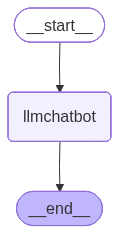

In [ ]:
# Visualization

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:
response = graph.invoke({"messages":"Hi"})
response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='8d0108c1-3bcf-42fd-88f8-ff80d4287f15'),
  AIMessage(content='<think>\nOkay, the user said "Hi". That\'s a greeting. I should respond in a friendly and welcoming way. Let me make sure to acknowledge their greeting and offer assistance. Maybe something like, "Hello! How can I help you today?" That sounds good. Keep it simple and open-ended so they know I\'m here to help with whatever they need.\n</think>\n\nHello! How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 86, 'prompt_tokens': 9, 'total_tokens': 95, 'completion_time': 0.170627284, 'completion_tokens_details': None, 'prompt_time': 0.000806809, 'prompt_tokens_details': None, 'queue_time': 2.768514611, 'total_time': 0.171434093}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_d58dbe76cd', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'gr

In [13]:
response["messages"][-1].content

'<think>\nOkay, the user said "Hi". That\'s a greeting. I should respond in a friendly and welcoming way. Let me make sure to acknowledge their greeting and offer assistance. Maybe something like, "Hello! How can I help you today?" That sounds good. Keep it simple and open-ended so they know I\'m here to help with whatever they need.\n</think>\n\nHello! How can I help you today?'

In [26]:
for chunk in graph.stream({"messages":"Hi"}):
    print(chunk["llmchatbot"]["messages"][0].text)

<think>
Okay, the user said "Hi". That's pretty open-ended. I need to respond appropriately. Since they're greeting me, I should greet them back. Maybe ask how I can assist. Keep it friendly and open. Let me make sure the response is welcoming. Maybe something like, "Hello! How can I assist you today?" That should work. Check for any typos. Alright, that's good.
</think>

Hello! How can I assist you today?


In [32]:
for chunk in graph.stream({"messages":"Hi"}):
    for value in chunk.values():
        print(value["messages"][-1].content)

<think>
Okay, the user said "Hi". That's a greeting. I should respond politely. Maybe say hello and ask how I can help them today. Keep it friendly and open-ended so they feel comfortable to ask anything. Let me check if there's any specific way they want the response. Nope, just a standard greeting. Alright, go with that.
</think>

Hello! How can I assist you today? 😊


## Chatbot with Tool

In [1]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()
llm = ChatGroq(model='qwen/qwen3-32b')

In [2]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph?")

{'query': 'What is langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': '*   [Overview](https://www.ibm.com/think/topics/ai-agents#7281535). *   [What is agentic AI?](https://www.ibm.com/think/topics/agentic-ai#2095054954). *   [Overview](https://www.ibm.com/think/topics/ai-agent-development#1083937704). *   [Building AI agents](https://www.ibm.com/think/topics/how-to-build-an-ai-agent#1083937709). *   [Overview](https://www.ibm.com/think/topics/ai-agent-types#72820454). *   [Overview](https://www.ibm.com/think/topics/components-of-ai-agents#498277090). *   [Communication](https://www.ibm.com/think/topics/ai-agent-communication#498277088). *   [Learning](https://www.ibm.com/think/topics/ai-agent-learning#498277087). *   [Memory](https://www.ibm.com/think/topics/ai-agent-memory#498277086). *   [Perception](https://www.ibm.com/think/topics/ai-agen

In [3]:
# Custom Function

def multiply(a:int, b:int) -> int:
    """Multiply a and b
    
    Args:
        a (int) : first int
        b (int) : second int
    
    Returns:
        int: output int
    """
    return a*b

In [4]:
tools = [tool,multiply]
llm_with_tool = llm.bind_tools(tools)
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000013F5606D010>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000013F5606DD30>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for com

In [5]:
# StateGraph
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

class State(TypedDict):
    # Messages have the type "list". The add_messages function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)

    messages: Annotated[list,add_messages]

graph_builder = StateGraph(State)
graph_builder

In [7]:
# Node Definition

def chatbot_with_tool(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

In [8]:
graph_builder = StateGraph(State)

# Adding a Node
graph_builder.add_node("chatbot_with_tool",chatbot_with_tool)
graph_builder.add_node("tools",ToolNode(tools))

# Adding edge
graph_builder.add_edge(START,"chatbot_with_tool")
graph_builder.add_conditional_edges(
    "chatbot_with_tool",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
graph_builder.add_edge("tools",END)

# Compile
graph = graph_builder.compile()

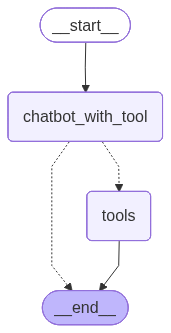

In [9]:
# Visualization

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [25]:
response = graph.invoke({"messages":"What is the recent AI news?"})
response

{'messages': [HumanMessage(content='What is the recent AI news?', additional_kwargs={}, response_metadata={}, id='57731e4a-d97a-4665-8616-fd1c82eaed8d'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent AI news. Let me see which tool to use here. The available tools are tavily_search and multiply. Multiply is for math operations, so that\'s not relevant here. Tavily_search is the search engine tool.\n\nLooking at the parameters for tavily_search, I need to set up the query. The user wants recent news, so the query should be "recent AI news". The topic parameter should be "news" since it\'s about current events. The time_range should probably be "week" or "day" to get the latest articles. Let me check the description again. It says to use "news" for politics, sports, or major current events. AI news would fall under current events, so topic is set to "news". \n\nFor time_range, the user didn\'t specify a specific period, but "recent" u

In [11]:
for chunk in graph.stream({"messages":"What is 5*3?"}):
    for value in chunk.values():
        print(value["messages"][-1].content)


15


In [26]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (44a3khnbn)
 Call ID: 44a3khnbn
  Args:
    include_images: True
    query: recent AI news
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": ["https://images.squarespace-cdn.com/content/v1/674381bfcb2cfc0398d60958/1782221751090-J7DOV5C3FFU1HQBD4C2O/Thumbnail-video-2-600x400.png", "https://unrot.co/_next/image?url=https%3A%2F%2Fbuildfastwithai.s3.eu-north-1.amazonaws.com%2Funrot-blog-images%2Fa87e7cda-6c6d-4abd-8295-08cd4507830e-09307aff-352d-4838-a6f4-ccf56a044c12.png&w=3840&q=75", "https://i.ytimg.com/vi/l7QzYSF4uaM/hq720.jpg?sqp=-oaymwEhCK4FEIIDSFryq4qpAxMIARUAAAAAGAElAADIQj0AgKJD&rs=AOn4CLCDsh1S1vqz

In [27]:
response = graph.invoke({"messages":"What is 5*15?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5*15?
================================== Ai Message ==================================
Tool Calls:
  multiply (22ydqbrdg)
 Call ID: 22ydqbrdg
  Args:
    a: 5
    b: 15
================================= Tool Message =================================
Name: multiply

75
